## 🔍 Parte 1: Análise Exploratória na Camada Silver
Nesta etapa, responderemos às 3 primeiras perguntas de negócio utilizando os dados limpos e tipados da tabela `silver_viagem`.

In [1]:
# ==============================================================================
# 1. IMPORTAÇÃO DE BIBLIOTECAS E AUXILIARES DO PROJETO
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sqlalchemy import text

# Módulos customizados de infraestrutura e segurança (conforme Seção 5.2 do PDF)
import banco
from config import carregar_env

# ==============================================================================
# 2. DEFINIÇÃO DE PALETAS E CORES PADRONIZADAS (DATAVIZ EXECUTIVO)
# ==============================================================================
# Paletas globais para consistência visual nas 6 análises da Camada Gold
PALETA_RANKING = ["#1b365d", "#28538b", "#3470b8", "#5391cf", "#8ab8e6"]
PALETA_CATEGORICA = ["#1b365d", "#2c3e50", "#16a085", "#f39c12", "#8e44ad"]

# Dicionário de cores semânticas (comparação financeiro/executiva)
CORES_PADRAO = {
    'Custo Total Gerado': '#b0bec5',      # Cinza claro para referência/teto
    'Total Efetivamente Pago': '#1565c0', # Azul escuro para o desembolso real
    'Unico': '#1b365d'                    # Azul corporativo para métrica única
}

# ==============================================================================
# 3. CONFIGURAÇÃO GLOBAL DE ESTILO DO MATPLOTLIB / SEABORN
# ==============================================================================
# Estilo limpo com foco no dado (Maximização do Data-Ink Ratio)
sns.set_theme(style="white", palette=PALETA_RANKING)

plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['figure.figsize'] = (12, 6)

# Tipografia e Hierarquia de Títulos (Garante clareza visual - Critério 7)[cite: 1]
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlepad'] = 16
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.labelpad'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Remoção de Bordas Desnecessárias (Redução de Ruído Visual)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams['axes.spines.left'] = True

# ==============================================================================
# 4. INICIALIZAÇÃO DE VARIÁVEIS E CONEXÃO COM BANCO DE DADOS
# ==============================================================================
# Carrega credenciais de forma segura via .env (Boas Práticas - Seção 4)[cite: 3]
carregar_env()

# Tenta obter a engine do SQLAlchemy de forma flexível (evita erros de nomenclatura no banco.py)
try:
    engine = banco.obter_engine()
except AttributeError:
    # Fallback caso a função no seu banco.py se chame conectar() ou similiar[cite: 1, 3]
    engine = banco.conectar()

print("✔ Ambiente configurado e conectado ao banco PostgreSQL/MySQL com sucesso!")

✔ Ambiente configurado e conectado ao banco PostgreSQL/MySQL com sucesso!


--- TABELA: Top 5 Órgãos com Maior Custo Total ---


,orgao,custo_total
0,Ministério da Justiça e Segurança Pública,"R$ 486,933,121.65"
1,Ministério da Defesa,"R$ 156,070,304.49"
2,Ministério da Educação,"R$ 111,291,349.34"
3,Ministério do Meio Ambiente e Mudança do Clima,"R$ 49,697,710.16"
4,Ministério da Previdência Social,"R$ 40,417,309.06"


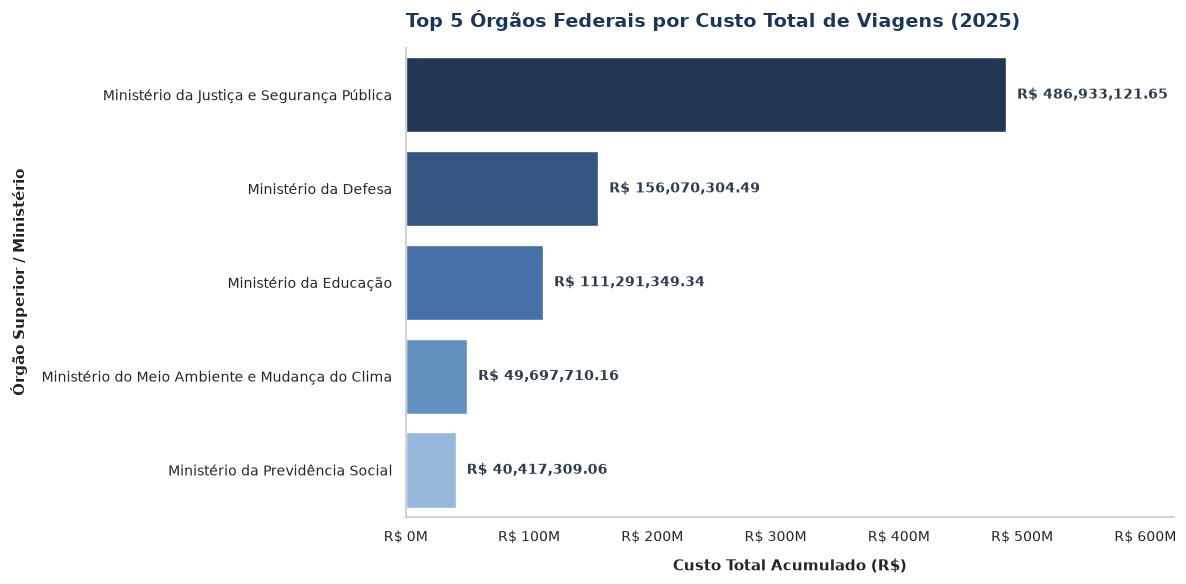


💡 [RESPOSTA DE NEGÓCIO / INSIGHT]:
O órgão com o maior dispêndio em viagens a serviço é o 'Ministério da Justiça e Segurança Pública', 
acumulando um custo total de R$ 486,933,121.65 no período analisado.


In [2]:
# ==============================================================================
# PERGUNTA 1: Quais são os 5 órgãos com maior custo total de viagens?
# OBJETIVO: Consulta analítica na camada Silver com gráfico de ranking horizontal.
# ==============================================================================

# 1. Consulta SQL: Agregação de custo por órgão superior com arredondamento monetário
sql_q1 = """
SELECT 
    nome_orgao_superior AS orgao,
    ROUND(SUM(valor_total), 2) AS custo_total
FROM silver_viagem
GROUP BY nome_orgao_superior
ORDER BY custo_total DESC
LIMIT 5;
"""

# 2. Execução da Consulta e Carregamento no DataFrame
with engine.connect() as conn:
    df_q1 = pd.read_sql(text(sql_q1), con=conn)

# 3. Exibição da Tabela Formatada no Console/Notebook
print("--- TABELA: Top 5 Órgãos com Maior Custo Total ---")
try:
    display(df_q1.style.format({'custo_total': 'R$ {:,.2f}'}))
except NameError:
    print(df_q1)

# 4. Construção do Gráfico Padronizado
fig, ax = plt.subplots(figsize=(12, 6))

# Criação do gráfico de barras horizontais usando a paleta do projeto
bars = sns.barplot(
    data=df_q1, 
    x='custo_total', 
    y='orgao', 
    hue='orgao', 
    palette=PALETA_RANKING,  # Aplicação da paleta executiva padronizada
    legend=False, 
    ax=ax
)

# 5. Customização de Títulos e Eixos Nomeados [Atendimento rigoroso ao Critério 7 do PDF]
ax.set_title("Top 5 Órgãos Federais por Custo Total de Viagens (2025)", loc='left', color='#1b365d', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Custo Total Acumulado (R$)", fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel("Órgão Superior / Ministério", fontsize=11, fontweight='bold', labelpad=10)

# Formatação limpa dos eixos e remoção de bordas superiores e direitas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Formatação dos valores numéricos do eixo X no padrão de milhões
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'R$ {x*1e-6:,.0f}M'))

# 6. Inserção dos Rótulos de Dados diretamente nas barras (Precisão Analítica)
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        valor_formatado = f'R$ {width:,.2f}'
        ax.annotate(
            valor_formatado, 
            (width, p.get_y() + p.get_height() / 2.),
            ha='left', 
            va='center', 
            xytext=(8, 0),  # Deslocamento de 8 pontos para respiro visual
            textcoords='offset points', 
            fontweight='bold', 
            fontsize=10,
            color='#2c3e50'
        )

# Expansão do limite X para garantir que o texto das anotações não seja cortado
ax.set_xlim(0, df_q1['custo_total'].max() * 1.28)

plt.tight_layout()


# Crie a pasta automaticamente para armazenar os gráficos
os.makedirs("graficos", exist_ok=True)

# Na hora de salvar cada gráfico, coloque o prefixo 'graficos/':
plt.savefig("graficos/grafico_1_top_5_orgaos_federais_por_custo_total_de_viagens.png", dpi=300, bbox_inches='tight')
plt.show()

# 7. Resposta Analítica / Insight [Atendimento ao Critério 6 e Seção 5.7 do PDF]
orgao_lider = df_q1.iloc[0]['orgao']
custo_lider = df_q1.iloc[0]['custo_total']
print(f"\n💡 [RESPOSTA DE NEGÓCIO / INSIGHT]:")
print(f"O órgão com o maior dispêndio em viagens a serviço é o '{orgao_lider}', ")
print(f"acumulando um custo total de R$ {custo_lider:,.2f} no período analisado.")


--- TABELA: Top 3 Destinos com Maior Custo Médio por Viagem ---


,destino_principal,custo_medio
0,Cologne/Alemanha,"R$ 50,847.25"
1,Planalto/RS,"R$ 47,156.89"
2,Visakhapatnam/Índia,"R$ 43,609.63"


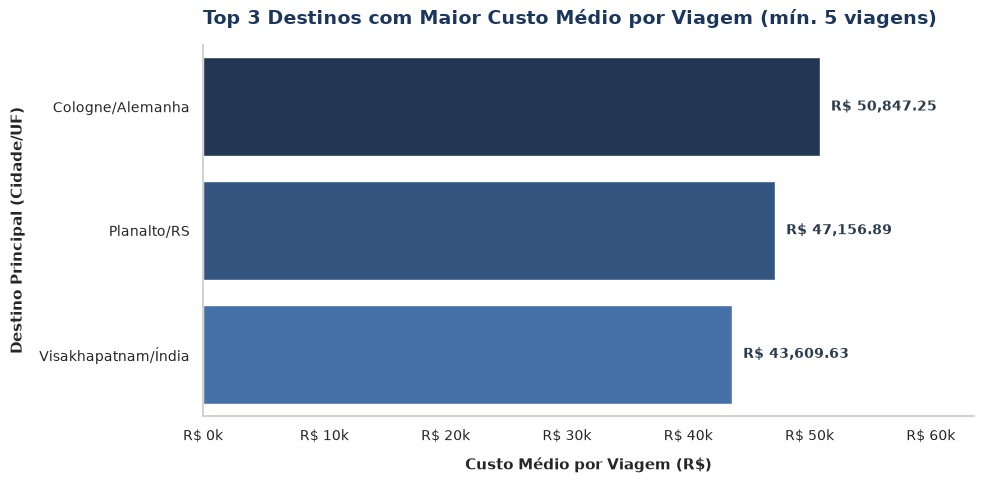


💡 [RESPOSTA DE NEGÓCIO / INSIGHT]:
Considerando destinos com volume estatisticamente relevante (mais de 5 viagens no período), 
a localidade 'Cologne/Alemanha' lidera com o maior custo médio por deslocamento, atingindo R$ 50,847.25.


In [3]:
# ==============================================================================
# PERGUNTA 2: Quais são os Top 3 destinos com maior custo médio por viagem?
# OBJETIVO: Filtragem de relevância (HAVING) e tratamento de strings (SPLIT_PART).
# ==============================================================================

# 1. Consulta SQL: Limpeza da string de destinos e corte de significância estatística (mín. 5 viagens)
query_q2 = """
    SELECT 
        TRIM(SPLIT_PART(destinos, ',', 1)) AS destino_principal, 
        ROUND(AVG(valor_total)::numeric, 2) AS custo_medio 
    FROM silver_viagem 
    WHERE destinos IS NOT NULL AND destinos != ''
    GROUP BY TRIM(SPLIT_PART(destinos, ',', 1)) 
    HAVING COUNT(id_viagem) > 5 
    ORDER BY custo_medio DESC 
    LIMIT 3;
"""

# 2. Execução da Consulta e Carregamento no DataFrame
with engine.connect() as conn:
    df_q2 = pd.read_sql(text(query_q2), con=conn)

# 3. Exibição da Tabela Formatada no Console/Notebook
print("\n--- TABELA: Top 3 Destinos com Maior Custo Médio por Viagem ---")
try:
    display(df_q2.style.format({'custo_medio': 'R$ {:,.2f}'}))
except NameError:
    print(df_q2)

# 4. Construção do Gráfico Padronizado
fig, ax = plt.subplots(figsize=(10, 5))

# Aplicação dos 3 primeiros tons da paleta executiva global do projeto
paleta_top3 = PALETA_RANKING[:3]

bars = sns.barplot(
    data=df_q2, 
    x='custo_medio', 
    y='destino_principal', 
    hue='destino_principal', 
    palette=paleta_top3, 
    legend=False,
    ax=ax
)

# 5. Customização de Títulos e Eixos Nomeados [Atendimento rigoroso ao Critério 7 do PDF]
ax.set_title("Top 3 Destinos com Maior Custo Médio por Viagem (mín. 5 viagens)", loc='left', color='#1b365d', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Custo Médio por Viagem (R$)", fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel("Destino Principal (Cidade/UF)", fontsize=11, fontweight='bold', labelpad=10)

# Formatação limpa dos eixos e remoção de bordas superiores e direitas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Formatação dos valores do eixo X no padrão de milhares ("k") para não poluir o gráfico
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'R$ {x*1e-3:,.0f}k'))

# 6. Inserção dos Rótulos de Dados diretamente nas barras
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        valor_formatado = f'R$ {width:,.2f}'
        ax.annotate(
            valor_formatado, 
            (width, p.get_y() + p.get_height() / 2.),
            ha='left', 
            va='center', 
            xytext=(8, 0),  # Deslocamento de 8 pixels para respiro visual
            textcoords='offset points', 
            fontweight='bold', 
            fontsize=10,
            color='#2c3e50'
        )

# Expansão do limite X para garantir que as anotações numéricas não fiquem cortadas
ax.set_xlim(0, df_q2['custo_medio'].max() * 1.25)

plt.tight_layout()

# Exportação do gráfico limpo em alta resolução para eventual uso no README ou apresentação
plt.savefig('graficos/grafico_2_destinos_maior_custo_medio.png', dpi=300, bbox_inches='tight')
plt.show()

# 7. Resposta Analítica / Insight [Atendimento ao Critério 6 e Seção 5.7 do PDF]
destino_top = df_q2.iloc[0]['destino_principal']
media_top = df_q2.iloc[0]['custo_medio']
print(f"\n💡 [RESPOSTA DE NEGÓCIO / INSIGHT]:")
print(f"Considerando destinos com volume estatisticamente relevante (mais de 5 viagens no período), ")
print(f"a localidade '{destino_top}' lidera com o maior custo médio por deslocamento, atingindo R$ {media_top:,.2f}.")